# Part A — Supervised model + metrics (70 marks)

Q1. SVM & DecisionTree Classifier on Wine dataset + metrics + confusion matrix plot (70 marks)

Use sklearn’s wine dataset.

1. Load the dataset (X, y). Split into train/test (75/25, fixed random_state 45).
2. Build a pipeline with:

(For SVM)
* StandardScaler
* SVM classifier (SVC) with RBF kernel (kernel="rbf", C=1.0, gamma="scale")

(For Decision Tree)
* Decision Tree classifier with max depth 20

3. Train the model on training set.
4. On the test set, print:

* Accuracy
* Precision
* Recall
* F1-score

5. Print the classification report.
6. Create a confusion matrix visualization.

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [48]:
# 1) Load the dataset
data = load_wine()
X, y = data.data, data.target
print("X shape:", X.shape)
print("y shape:", y.shape)

feature_names = data.feature_names
class_names = data.target_names
print("Classes:", class_names)
print("feature:", feature_names)
#Train-test split (75/25, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=45
)

X shape: (178, 13)
y shape: (178,)
Classes: ['class_0' 'class_1' 'class_2']
feature: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [49]:
# 2. Build pipeline
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=45))
])

In [50]:
# 3. Train the model on training set.
print("Training SVM model...")
svm_pipeline.fit(X_train, y_train)
print("SVM model trained.")

Training SVM model...
SVM model trained.


In [51]:
# 4. On the test set
y_pred = svm_pipeline.predict(X_test)
# Metrics

print("Accuracy:", accuracy_score(y_test, y_pred ))
print("Precision:", precision_score(y_test, y_pred, average = 'macro'))
print("Recall:", recall_score(y_test, y_pred, average = 'macro'))
print("F1-score:", f1_score(y_test, y_pred, average = 'macro'))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


In [52]:
#5. Print the classification report.
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



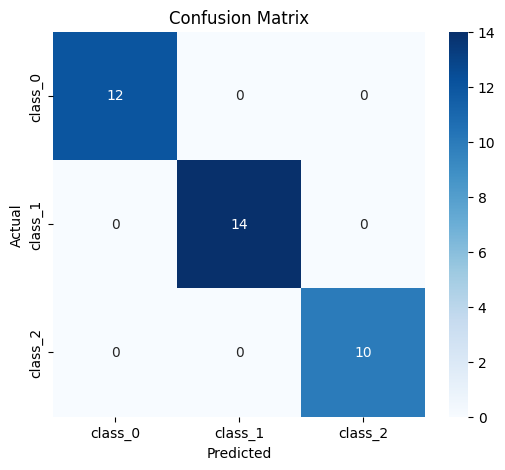

In [53]:
#6. Create a confusion matrix visualization.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Part B — Clustering + evaluation (20 marks)

Q4. KMeans on Wine Dataset + SSE (20)

Use Iris dataset for clustering.

1. Load Wine (X, y), but do clustering using X only (ignore labels for training).
2. Run KMeans with K=3.
3. Print
* SSE score

5. Make a 2D scatter plot using any two features (e.g., feature 0 vs feature 2) colored by cluster labels.

In [54]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load dataset
iris = load_iris()
X = iris.data  # ignore y

In [55]:
# 2. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [56]:
# 3. KMeans with K=3
kmeans = KMeans(n_clusters=3, random_state=45, n_init=10)
kmeans.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=45)

In [57]:
# 4. Outputs
print("Number of clusters found:", kmeans.n_clusters)
print("SSE (Inertia):", kmeans.inertia_)

Number of clusters found: 3
SSE (Inertia): 139.82049635974974


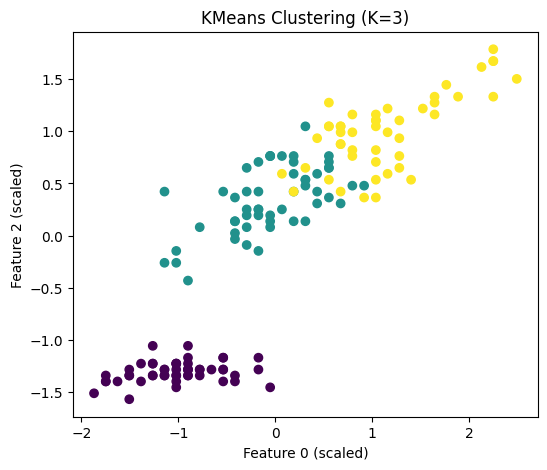

In [58]:
# 5. Scatter plot (feature 0 vs feature 2)
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 2],
            c=kmeans.labels_, cmap='viridis')

plt.xlabel("Feature 0 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.title("KMeans Clustering (K=3)")
plt.show()

In [59]:
# Hint: Covert the dataset to a pandas dataframe for Part B

# Part C - Submission (10 marks)
Submit notebook as: Lab5_Name_ID_Section.ipynb

Notebook must run from top to bottom without errors.